# 01 · Calidad de datos, pipeline y variables derivadas — Caso 15 · Caja Rural 360

Continúa el trabajo del notebook 00_negocio_y_poblacion: parte de la **población PD ya definida** (`data.pd_population`) y del **catálogo de variables** (qué está disponible en T0 y qué está prohibido), y sobre esa base construye el perfilado de calidad, el pipeline de tratamiento y las variables derivadas. La narrativa está en `reports/03_data_strategy_calidad_features.md`.

| Sección | Contenido |
|---|---|
| 1 | Punto de partida: población y variables heredadas de 6.2 |
| 2 | Completitud y mecanismo de los faltantes |
| 3 | Duplicidad |
| 4 | Consistencia y lógica de negocio |
| 5 | Rangos y outliers |
| 6 | Cardinalidad |
| 7 | Estabilidad temporal de variables y del target |
| 8 | Variables derivadas: construcción, pre-selección en DEV y documentación |
| 9 | Pipeline reproducible de faltantes y categóricas |
| 10 | Data Dictionary técnico |
| 11 | Persistencia y resumen de decisiones |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, data_dictionary, features, pipeline, quality, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


## 1. Punto de partida: lo que viene de 6.2

El perfilado se hace sobre la **población PD** (aprobados con resultado observado) y, cuando el control lo requiere, sobre la base completa de solicitudes (TTD). Las variables a perfilar son las **candidatas** del catálogo: las disponibles en T0 y no prohibidas por leakage.

In [2]:
raw = data.load_raw()
pop, _ = data.pd_population(raw)
pop["year"] = pop[cfg.DATE_COL].dt.year

candidatas = data.pd_candidate_features()
cat_cols = ["region", "channel", "employment_type"]
num_cands = [c for c in candidatas if c not in cat_cols]

print(f"Solicitudes totales (TTD): {len(raw):,} | Población PD: {len(pop):,} | Default: {pop[cfg.TARGET].mean():.2%}")
print(f"Variables candidatas heredadas de 6.2: {len(candidatas)} ({len(num_cands)} numéricas, {len(cat_cols)} categóricas)")
print("Prohibidas por leakage/endogeneidad:", data.forbidden_pd_features())

Solicitudes totales (TTD): 7,000 | Población PD: 5,783 | Default: 11.60%
Variables candidatas heredadas de 6.2: 20 (17 numéricas, 3 categóricas)
Prohibidas por leakage/endogeneidad: ['annual_interest_rate_offer', 'approved_flag', 'outcome_available_flag', 'default_12m_flag', 'ead_at_default', 'balance_at_default', 'recovery_amount_total', 'recovery_cost_total', 'months_to_recovery', 'lgd_observed']


## 2. Completitud y mecanismo de los faltantes

Se mide sobre la población PD y abierta por muestra temporal, para verificar que el faltante no aparezca ni desaparezca con el tiempo (lo que obligaría a imputar distinto en producción).

In [3]:
comp = quality.completeness(pop, candidatas, by="sample")[["DEV", "VAL", "OOT", "total"]]
display(comp[comp["total"] > 0])
print("Variables sin ningún faltante:", int((comp["total"] == 0).sum()), "de", len(comp))
comp.to_csv(cfg.TABLES / "calidad_completitud.csv")

,DEV,VAL,OOT,total
savings_balance,0.0741,0.0782,0.0849,0.0771
bureau_score,0.0366,0.0313,0.0261,0.0334
monthly_income,0.0247,0.0235,0.0278,0.0251


Variables sin ningún faltante: 17 de 20


Solo tres variables tienen faltantes y ninguna supera el 8%: `savings_balance` (7.7%), `bureau_score` (3.3%) y `monthly_income` (2.5%). La tasa es **estable entre muestras** (por ejemplo, buró: 3.7% en DEV, 3.1% en VAL, 2.6% en OOT), así que la regla de imputación ajustada en DEV sigue siendo válida en las cosechas siguientes.

Antes de decidir cómo tratarlos hay que saber **por qué faltan**. Si el faltante depende de otras variables (MAR) o del propio riesgo, imputar sin más sesga el modelo; si es aleatorio (MCAR), basta con imputar. Se evalúan tres preguntas:

1. **Estabilidad:** ¿la tasa de faltante cambia por año o con la decisión de aprobación? (todas las solicitudes)
2. **MCAR vs. MAR:** ¿las demás variables de T0 permiten predecir quién tiene el dato faltante? Logit con 26 covariables, test de razón de verosimilitud y AUC con validación cruzada.
3. **¿Es informativo del riesgo?** Default con y sin faltante en DEV, controlado por el núcleo de riesgo y por subperiodo de DEV. VAL se muestra solo como información.


In [4]:
faltantes = quality.missingness_report(raw, pop, candidatas, cat_cols)
display(faltantes.set_index("variable").T)
faltantes.to_csv(cfg.TABLES / "faltantes_mecanismo.csv", index=False)

# ¿Quien no tiene score de buró es realmente thin-file (sin historial)?
historial = quality.bureau_history_check(raw)
display(historial)
historial.to_csv(cfg.TABLES / "faltantes_historial_buro.csv", index=False)


variable,monthly_income,bureau_score,savings_balance
pct_faltante_ttd,0.0243,0.0327,0.0771
p_tasa_por_anio,0.5248,0.1497,0.6534
p_relacion_aprobacion,0.4122,0.5359,1.0000
p_modelo_faltante,0.5366,0.3818,0.3399
auc_cv_modelo_faltante,0.4958,0.5105,0.5050
n_faltante_dev,85,126,255
defaults_faltante_dev,7,6,23
dr_faltante_dev,0.0824,0.0476,0.0902
dr_resto_dev,0.1024,0.1040,0.1029
p_default_dev,0.7159,0.0358,0.5910


,variable_de_buro,media_sin_score,media_con_score,p_ks
0,active_loans,2.0000,2.0146,0.9941
1,prior_delinquencies_24m,0.5371,0.5651,1.0000
2,bureau_inquiries_6m,1.9301,1.7870,0.7217
3,monthly_debt_payment,"1,211.2018","1,176.0815",0.5499
4,% con al menos 1 deuda activa,0.8865,0.8687,NaN
5,% con mora previa en 24m,0.4323,0.4305,NaN


**Los tres faltantes son compatibles con MCAR.** Ninguno se puede predecir con las demás variables de la solicitud (AUC con validación cruzada entre 0.50 y 0.51; test de razón de verosimilitud con p entre 0.34 y 0.54), ninguno cambia por año de originación ni se relaciona con la aprobación histórica.

- **`monthly_income` y `savings_balance`: no informativos.** El default con y sin dato no difiere en DEV, ni controlando por buró y DTI (p = 0.70 y 0.31). El ahorro falta igual en clientes nuevos y antiguos, así que el faltante **no** identifica a quien no tiene ese producto en la Caja.
- **`bureau_score`: no es thin-file.** Quien no tiene score tiene el mismo historial de buró que el resto: igual número de deudas activas (88.6% con al menos una), igual mora previa (43.2%) e iguales consultas (KS con p > 0.5). Es un **score no disponible**, no un cliente sin historial.
- **Su menor default no es estable.** En DEV es 4.8% contra 10.4% (p = 0.02 controlando por DTI), pero la diferencia viene de 2021-2022 (1 default en 86 solicitudes) y desaparece en 2023 (12.5% vs 12.4%).

**Tratamiento:** imputación con la mediana de DEV, que para el score equivale a riesgo neutral. Los indicadores de faltante se calculan igual, pero **no entran al modelo**: con MCAR no aportan y, en el caso del buró, darle un peso propio trasladaría a producción un efecto de 2021-2022 que ya no se observa. Se usan en la política (re-consultar el buró, verificar el ingreso) y en el monitoreo de calidad de datos. En el scorecard (6.5), los bins de faltante deben recibir WOE neutral.

## 3. Duplicidad


In [5]:
clave_negocio = [cfg.DATE_COL, "age", "region", "channel", "employment_type", "monthly_income", "requested_amount"]
display(quality.duplicates_report(raw, clave_negocio))

,control,registros,pct
0,Identificador duplicado (application_id),0,0.0000
1,Fila idéntica en todas las columnas (sin ID),0,0.0000
2,Clave de negocio duplicada (observation_date +...,0,0.0000


No hay duplicados de identificador, ni filas repetidas, ni solicitudes con la misma combinación de fecha, perfil y monto. No se requiere deduplicación.

## 4. Consistencia y lógica de negocio

Cada regla marca **violaciones**: mientras más cerca de cero, mejor. Se evalúan tanto reglas aritméticas (que una variable derivada del archivo cuadre con sus insumos) como reglas de negocio (edad de elegibilidad, coherencia entre campos post-default, plausibilidad del ingreso).

In [6]:
reglas = quality.consistency_rules(pop)
display(reglas[["regla", "severidad", "violaciones", "pct", "tratamiento"]])
reglas.to_csv(cfg.TABLES / "calidad_reglas_consistencia.csv", index=False)
print("Reglas evaluadas:", len(reglas), "| con violaciones:", int((reglas.violaciones > 0).sum()))

,regla,severidad,violaciones,pct,tratamiento
4,relación con la Caja <= (edad - 18) * 12,Baja,160,0.0277,Se conserva: es plausible una cuenta de ahorro...
1,dti informado con ingreso faltante,Media,145,0.0251,Imposible en producción (dti = cuota / ingreso...
18,"ingreso mensual >= S/ 1,025 (referencia)",Informativa,103,0.0178,Se conservan: en el segmento rural informal un...
3,antigüedad laboral <= (edad - 14) * 12,Media,81,0.0140,Se conserva el registro; la winsorización p1-p...
17,cuota estimada <= ingreso mensual,Alta,1,0.0002,Caso aislado: la solicitud es inviable por cap...
0,dti = cuota de deuda / ingreso (filas con ingr...,Alta,0,0.0000,Sin violaciones: el dti del archivo es coheren...
2,new_customer_flag = 1 <-> relationship_months = 0,Alta,0,0.0000,Sin violaciones.
7,"cash_income_share dentro de [0, 1]",Alta,0,0.0000,Sin violaciones.
8,dti <= 1,Alta,0,0.0000,Sin violaciones.
10,plazo dentro del catálogo del producto,Alta,0,0.0000,Sin violaciones.


Reglas evaluadas: 20 | con violaciones: 5


De 20 reglas, **15 se cumplen sin excepción** y 5 arrojan hallazgos, ninguno bloqueante:

1. **`relationship_months` mayor a la edad adulta posible (160 casos, 2.8%).** Severidad baja: es plausible que la relación con la Caja haya empezado con una cuenta de ahorros antes de los 18 años. Se conservan.
2. **`dti` informado con ingreso faltante (145 casos, 2.5%).** Severidad media: como `dti` = cuota de deudas / ingreso, sin ingreso no puede existir. Es un artefacto de la extracción que en producción no se daría. **El pipeline recalcula `dti` desde sus insumos**, así que en esas filas queda faltante y se imputa, igual que lo haría el servicio de scoring. Usar el `dti` del archivo sería entrenar con información que el modelo no tendrá.
3. **Ingreso menor a la referencia de S/ 1,025 (103 casos, 1.8%).** No es un error: en un segmento rural informal un ingreso por debajo del salario mínimo formal es plausible. Se conserva sin tratamiento.
4. **Antigüedad laboral mayor a la vida laboral posible (81 casos, 1.4%).** Se conserva el registro; la winsorización limita el extremo y se reporta al equipo de captura.
5. **Cuota estimada mayor al ingreso mensual (1 caso).** La solicitud es inviable por capacidad de pago.

## 5. Rangos y outliers

Se usa la regla de Tukey con k = 3 (muy por fuera del rango intercuartílico) para no confundir la cola natural de una cartera de microcrédito con errores.

In [7]:
out = quality.outlier_report(pop, num_cands)
display(out[["variable", "min", "p1", "mediana", "p99", "max", "asimetria", "outliers_iqr", "pct_outliers"]])
out.to_csv(cfg.TABLES / "calidad_outliers.csv", index=False)

,variable,min,p1,mediana,p99,max,asimetria,outliers_iqr,pct_outliers
9,savings_balance,45.3700,217.7748,"2,666.9000","29,199.6860","243,909.3900",11.2204,176,0.0330
14,distance_to_branch_km,0.5000,1.4000,9.0000,55.5360,150.0000,3.1862,123,0.0213
7,monthly_debt_payment,3.8200,66.1930,861.7900,"5,158.7510","21,395.7100",3.1576,78,0.0135
12,requested_amount,512.0100,"1,341.8184","6,314.3300","29,992.1476","78,915.4700",2.6536,74,0.0128
1,monthly_income,529.2300,909.5519,"3,472.3650","12,725.3076","33,678.1500",1.9607,37,0.0066
2,employment_tenure_months,0.0000,4.0000,36.0000,124.1800,240.0000,1.2315,12,0.0021
11,relationship_months,0.0000,0.0000,13.0000,111.0000,180.0000,1.4136,9,0.0016
4,prior_delinquencies_24m,0.0000,0.0000,0.0000,3.0000,5.0000,1.4144,5,0.0009
6,active_loans,0.0000,0.0000,2.0000,6.0000,10.0000,0.6838,1,0.0002
0,age,18.0000,18.0000,38.0000,61.0000,71.0000,0.1066,0,0.0000


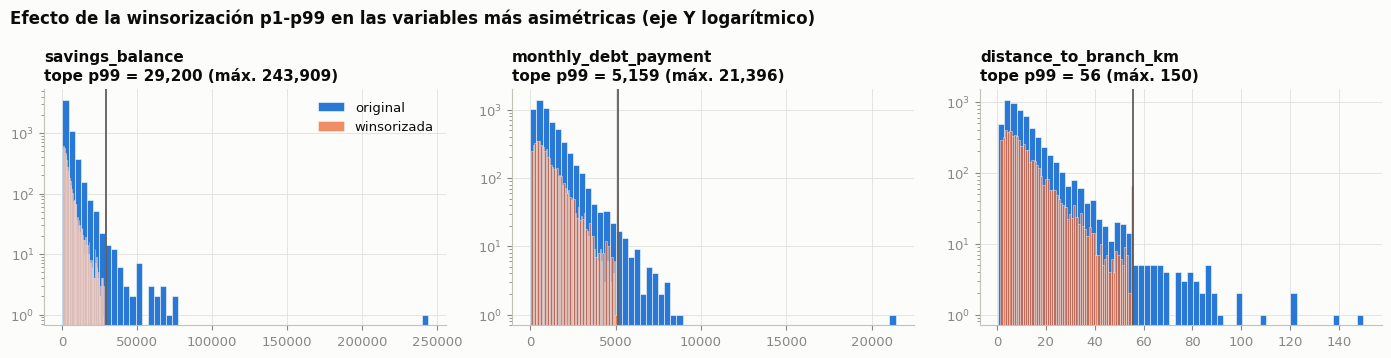

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["savings_balance", "monthly_debt_payment", "distance_to_branch_km"]):
    s = pop[col].dropna()
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    ax.hist(s, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.4, label="original")
    ax.hist(s.clip(lo, hi), bins=60, color=ORANGE, alpha=0.75, edgecolor=SURFACE, linewidth=0.4, label="winsorizada")
    ax.axvline(hi, color=INK_2, lw=1.2)
    ax.set_title(f"{col}\ntope p99 = {hi:,.0f} (máx. {s.max():,.0f})")
    ax.set_yscale("log")
axes[0].legend(loc="upper right")
fig.suptitle("Efecto de la winsorización p1-p99 en las variables más asimétricas (eje Y logarítmico)",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
savefig(fig, "fig08_winsorizacion")
plt.show()

Los mínimos y máximos están dentro de rangos plausibles del producto. También hay **colas largas**: `savings_balance` llega a S/ 243,909 (asimetría 11.2) frente a una mediana de S/ 2,667, y 3.3% de los registros quedan fuera del rango de Tukey. Le siguen `distance_to_branch_km` (2.1%) y `monthly_debt_payment` (1.4%).

**Decisión:** no se eliminan outliers (son clientes reales del producto y borrarlos sesgaría la PD), sino que se **acotan a p1-p99 dentro del pipeline**, con topes ajustados en DEV. Así un valor extremo no domina el ajuste de un modelo lineal, pero el registro conserva su información de riesgo.

## 6. Cardinalidad

In [9]:
card = quality.cardinality_report(pop, candidatas)
display(card)
card.to_csv(cfg.TABLES / "calidad_cardinalidad.csv", index=False)

,variable,tipo,n_unicos,pct_unicos,categorias_menores_al_umbral
13,new_customer_flag,int64,2,0.0003,
3,employment_type,object,4,0.0007,
2,channel,object,4,0.0007,
1,region,object,5,0.0009,
7,prior_delinquencies_24m,int64,6,0.0010,"3 (1.6%), 4 (0.2%), 5 (0.1%)"
16,term_months,float64,8,0.0014,
18,household_dependents,int64,9,0.0016,"5 (4.9%), 6 (1.7%), 7 (0.6%), 8 (0.1%)"
8,bureau_inquiries_6m,int64,10,0.0017,"5 (2.5%), 6 (0.6%), 7 (0.3%), 8 (0.0%), 9 (0.0%)"
9,active_loans,int64,11,0.0019,"5 (3.9%), 6 (1.4%), 7 (0.2%), 8 (0.1%), 10 (0...."
0,age,int64,54,0.0093,


Las tres variables categóricas tienen cardinalidad baja y manejable (4 a 5 niveles), y **ninguna categoría baja del 7%** de la población, así que no hace falta agrupar categorías raras ni aplicar encodings de alta cardinalidad: un one-hot simple es suficiente y mantiene la interpretabilidad.

Entre las numéricas, `cash_income_share`, `requested_amount`, `monthly_debt_payment`, `monthly_income` y `savings_balance` son prácticamente continuas (más del 90% de valores únicos), mientras que `prior_delinquencies_24m`, `bureau_inquiries_6m`, `active_loans` y `household_dependents` son discretas con pocos niveles, lo que las hace buenas candidatas a agrupación en el scorecard.

## 7. Estabilidad temporal de las variables y del target

Se mide con PSI tomando DEV como referencia. Umbrales estándar: menor a 0.10 estable, entre 0.10 y 0.25 alerta, mayor a 0.25 cambio material.

In [10]:
estab = quality.temporal_stability(pop, candidatas, cat_cols)
display(estab)
estab.to_csv(cfg.TABLES / "calidad_estabilidad_psi.csv", index=False)
print("Variables con PSI OOT >= 0.10:", int((estab["psi_oot"] >= 0.10).sum()))

target_estab = quality.target_stability(pop)
display(target_estab)

,variable,psi_val,psi_oot,semaforo
0,age,0.0143,0.0174,Verde
15,requested_amount,0.0088,0.0128,Verde
5,employment_tenure_months,0.0200,0.0128,Verde
6,bureau_score,0.0065,0.0114,Verde
11,dti,0.0025,0.0100,Verde
12,savings_balance,0.0066,0.0098,Verde
4,monthly_income,0.0104,0.0077,Verde
2,channel,0.0023,0.0072,Verde
14,relationship_months,0.0083,0.0055,Verde
19,cash_income_share,0.0066,0.0055,Verde


Variables con PSI OOT >= 0.10: 0


,creditos,defaults,default_rate,var_vs_periodo_previo
observation_date,,,,
2021,1181,102,0.0864,NaN
2022,1146,111,0.0969,0.1215
2023,1116,138,0.1237,0.2767
2024,1151,161,0.1399,0.1312
2025,1189,159,0.1337,-0.0440


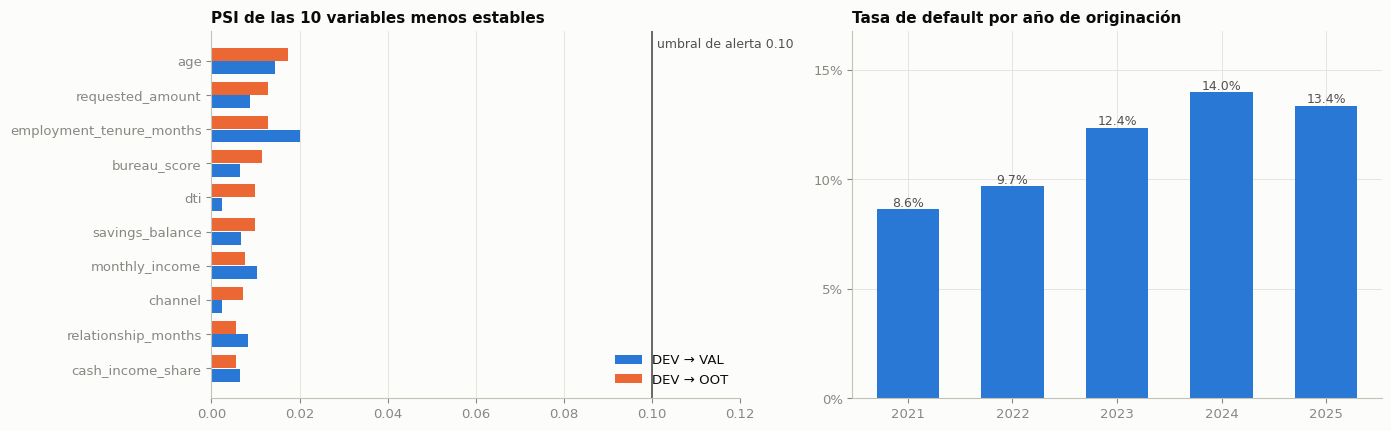

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
top = estab.head(10).iloc[::-1]
y = np.arange(len(top))
axes[0].barh(y - 0.2, top["psi_val"], height=0.38, color=BLUE, label="DEV → VAL")
axes[0].barh(y + 0.2, top["psi_oot"], height=0.38, color=ORANGE, label="DEV → OOT")
axes[0].axvline(0.10, color=INK_2, lw=1.2)
axes[0].text(0.101, len(top) - 0.6, "umbral de alerta 0.10", color=INK_2, fontsize=9)
axes[0].set_yticks(y, top["variable"])
axes[0].set_xlim(0, 0.12)
axes[0].set_title("PSI de las 10 variables menos estables")
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", visible=False)

t = target_estab.reset_index()
t["anio"] = t[cfg.DATE_COL].astype(str)
axes[1].bar(t["anio"], t["default_rate"], color=BLUE, width=0.6)
for x_, v in enumerate(t["default_rate"]):
    axes[1].text(x_, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
axes[1].set_title("Tasa de default por año de originación")
pct_axis(axes[1])
axes[1].set_ylim(0, t["default_rate"].max() * 1.2)
fig.tight_layout()
savefig(fig, "fig09_estabilidad_temporal")
plt.show()

**Las variables son estables; el target no.** El PSI máximo es 0.017 (`age`), muy por debajo del umbral de alerta: el perfil de quien solicita el crédito prácticamente no cambió entre 2021 y 2025. En cambio, la tasa de default sube de 8.6% a 14.0% y cierra en 13.4%, con un salto de +27.7% en 2023 y +13.1% en 2024.

Esto confirma con datos de calidad lo que ya se había detectado en 6.2: **el cambio es del entorno, no de la población**. Para el modelamiento significa que (a) no hace falta re-ajustar transformaciones ni imputaciones por drift de variables, y (b) sí hará falta recalibrar el nivel de PD, porque el mismo perfil de cliente incumple más que antes.

## 8. Variables derivadas

Dos pasos. Primero se construyen las variables que usa el pipeline: el `dti` recalculado, las derivadas conservadas y los indicadores de faltante. Después se muestra la evidencia de por qué se conservan esas y no otras: todas las derivadas propuestas se evaluaron con un protocolo decidido **solo con DEV**. Cada variable tiene fórmula, racional de negocio y signo esperado, y se calcula con insumos de T0 sin estadísticos de la muestra, para que el mismo código funcione en producción.


In [12]:
doc = features.feature_doc()
display(doc)
doc.to_csv(cfg.TABLES / "features_derivadas_doc.csv", index=False)

pop_fx = features.build_features(pop)
print("Variables que construye el pipeline:", ["dti (recalculado)"] + features.DERIVED_FEATURES)
print("Candidatas al modelo PD:", features.DERIVED_CANDIDATES)
print("Filas con ingreso faltante que quedan sin dti tras el recálculo:",
      int(pop_fx.loc[pop["monthly_income"].isna(), "dti"].isna().sum()), "de", int(pop["monthly_income"].isna().sum()))
display(pop_fx[["dti"] + features.DERIVED_FEATURES].describe(percentiles=[.01, .5, .99]).T)


,feature,formula,racional,signo_esperado,uso,candidata_pd
0,cuota_estimada,"monto * r / (1 - (1+r)^-plazo), con r = (1+TEA...",Cuota mensual del crédito solicitado; insumo d...,-,Insumo (no predictor),False
1,dti_post,(monthly_debt_payment + cuota_estimada) / mont...,Carga total de deuda si se aprueba el crédito....,+,Candidata PD (6.5 elige entre dti y dti_post) ...,True
2,ahorro_sobre_monto,savings_balance / requested_amount,Colchón de ahorro frente al tamaño del crédito...,-,Candidata PD (6.5 elige entre ella y savings_b...,True
3,flag_sin_buro,1 si bureau_score es nulo,Score de buró no disponible. No identifica un ...,?,Política y monitoreo (no predictor),False
4,flag_sin_ingreso,1 si monthly_income es nulo,Sin ingreso no hay capacidad de pago calculabl...,?,Política y monitoreo (no predictor),False
5,flag_sin_ahorro,1 si savings_balance es nulo,Faltante compatible con MCAR: igual en cliente...,?,Monitoreo (no predictor),False


Variables que construye el pipeline: ['dti (recalculado)', 'cuota_estimada', 'dti_post', 'ahorro_sobre_monto', 'flag_sin_buro', 'flag_sin_ingreso', 'flag_sin_ahorro']
Candidatas al modelo PD: ['dti_post', 'ahorro_sobre_monto']
Filas con ingreso faltante que quedan sin dti tras el recálculo: 145 de 145


,count,mean,std,min,1%,50%,99%,max
dti,"5,638.0000",0.2832,0.1602,0.0024,0.0250,0.2624,0.7078,0.8590
cuota_estimada,"5,783.0000",617.7819,655.6923,19.8382,57.5117,401.4953,"3,094.7183","8,135.9195"
dti_post,"5,638.0000",0.4337,0.1948,0.0488,0.1025,0.4140,0.9599,1.3696
ahorro_sobre_monto,"5,337.0000",0.6548,0.7452,0.0123,0.0460,0.4164,3.8058,9.4365
flag_sin_buro,"5,783.0000",0.0334,0.1796,0.0000,0.0000,0.0000,1.0000,1.0000
flag_sin_ingreso,"5,783.0000",0.0251,0.1564,0.0000,0.0000,0.0000,1.0000,1.0000
flag_sin_ahorro,"5,783.0000",0.0771,0.2668,0.0000,0.0000,0.0000,1.0000,1.0000


### Pre-selección: ¿qué derivadas aportan información?

**Por qué no alcanza con el AUC univariado "orientado al riesgo".** Ese AUC es max(AUC, 1 − AUC): pierde la dirección de la relación y está sesgado hacia arriba. Una variable de puro ruido ya marca ~0.51 en DEV y ~0.52 en VAL (celda siguiente), y un cambio de signo entre muestras pasa inadvertido. Por eso la evaluación usa el **AUC con dirección**, su **p-valor** (Mann-Whitney) y el **aporte incremental** sobre lo que la variable ya contiene.

**Protocolo (decidido solo con DEV; VAL se muestra como información y OOT no se consulta):**


In [13]:
display(features.rules_doc())

# Referencia: el AUC "doblado" que usaba la versión anterior, bajo ruido puro.
rng = np.random.default_rng(cfg.SEED)
ruido = {}
for s in ["DEV", "VAL"]:
    y_s = pop.loc[pop["sample"] == s, cfg.TARGET]
    sims = np.array([validation.univariate_auc(y_s, pd.Series(rng.random(len(y_s)), index=y_s.index)) for _ in range(1000)])
    ruido[s] = {"media": sims.mean(), "p95": np.quantile(sims, 0.95)}
display(pd.DataFrame(ruido).T.rename_axis("AUC doblado de una variable aleatoria"))


,regla,criterio
0,R1,Señal en DEV con el signo esperado (Mann-Whitn...
1,R2,Mantiene el signo esperado en 2021-2022 y en 2...
2,R3,Aporta sobre el núcleo y sus propios component...
3,R4,"Si usa una variable sensible, esta aporta sobr..."
4,R5,No es redundante con otra derivada que pasa R1...


,media,p95
AUC doblado de una variable aleatoria,,
DEV,0.5129,0.5313
VAL,0.5193,0.5468


In [14]:
pool = features.build_candidate_pool(pop)
dev_pool = pool[pool["sample"] == "DEV"]
ev = features.screen_derived_features(dev_pool)

# Información complementaria que NO interviene en la decisión: AUC con dirección en VAL y PSI DEV -> OOT (sin target).
val_pool, oot_pool = pool[pool["sample"] == "VAL"], pool[pool["sample"] == "OOT"]
ev["auc_val_info"] = [validation.auc_raw(val_pool[cfg.TARGET], val_pool[f]) for f in ev.feature]
ev["psi_oot"] = [validation.psi(dev_pool[f], oot_pool[f]) for f in ev.feature]
ev["pct_na"] = [pool[f].isna().mean() for f in ev.feature]
display(ev.drop(columns=["formula", "motivo"]))
ev.to_csv(cfg.TABLES / "features_evaluacion.csv", index=False)
print("Conservadas:", ev.loc[ev.decision == "Conservada", "feature"].tolist())
print("Descartadas:", ev.loc[ev.decision == "Descartada", "feature"].tolist())


,feature,signo_esperado,auc_dev,p_dev,auc_dev_2021_2022,auc_dev_2023,p_aporte_sobre_componentes,p_necesidad_sensible,R1,R2,R3,R4,R5,redundante_con,decision,auc_val_info,psi_oot,pct_na
0,dti_post,+,0.5702,0.0000,0.5798,0.5569,0.0869,NaN,True,True,True,True,True,,Conservada,0.5380,0.0067,0.0251
1,ahorro_sobre_monto,-,0.4597,0.0166,0.4864,0.4177,0.0851,NaN,True,True,True,True,True,,Conservada,0.4521,0.0091,0.0771
2,colchon_ahorro_meses,-,0.4631,0.0282,0.4853,0.4292,0.0912,NaN,True,True,True,True,False,ahorro_sobre_monto,Descartada,0.4571,0.0119,0.0771
3,deuda_por_obligacion,+,0.5443,0.0064,0.5671,0.5092,0.5190,NaN,True,True,False,True,True,,Descartada,0.5546,0.0018,0.0000
4,dti_post_verificable,+,0.5479,0.0036,0.5501,0.5453,0.2548,0.2289,True,True,False,False,True,,Descartada,0.5267,0.0051,0.0251
5,excedente_per_capita,-,0.4634,0.0259,0.4465,0.4866,0.9425,0.9720,True,True,False,False,True,,Descartada,0.5221,0.0037,0.0251
6,antiguedad_relativa,-,0.4852,0.3617,0.5008,0.4597,0.7255,0.2511,False,False,False,False,True,,Descartada,0.5236,0.0196,0.0000
7,intensidad_busqueda,+,0.5140,0.3845,0.5365,0.4793,0.2488,NaN,False,False,False,True,True,,Descartada,0.5197,0.0038,0.0000
8,campana_siembra,+,0.4887,0.3885,0.4854,0.4932,0.2858,NaN,False,False,False,True,True,,Descartada,0.5270,0.0000,0.0000
9,loan_to_income,+,0.5013,0.9353,0.4866,0.5214,0.1618,NaN,False,False,False,True,True,,Descartada,0.5276,0.0077,0.0251


Conservadas: ['dti_post', 'ahorro_sobre_monto']
Descartadas: ['colchon_ahorro_meses', 'deuda_por_obligacion', 'dti_post_verificable', 'excedente_per_capita', 'antiguedad_relativa', 'intensidad_busqueda', 'campana_siembra', 'loan_to_income']


In [15]:
# dti vs dti_post: ¿alguna aporta sobre la otra? Lineal y por tramos (como un scorecard); VAL solo como información.
comparacion = pd.DataFrame({
    "agregar dti_post sobre buró + dti": [validation.lr_test(dev_pool, cfg.TARGET, ["bureau_score", "dti"], ["dti_post"]),
                                          validation.lr_test_binned(dev_pool, cfg.TARGET, ["bureau_score", "dti"], ["dti_post"]),
                                          validation.lr_test(val_pool, cfg.TARGET, ["bureau_score", "dti"], ["dti_post"])],
    "agregar dti sobre buró + dti_post": [validation.lr_test(dev_pool, cfg.TARGET, ["bureau_score", "dti_post"], ["dti"]),
                                          validation.lr_test_binned(dev_pool, cfg.TARGET, ["bureau_score", "dti_post"], ["dti"]),
                                          validation.lr_test(val_pool, cfg.TARGET, ["bureau_score", "dti_post"], ["dti"])],
}, index=["DEV lineal", "DEV por tramos", "VAL lineal (info)"]).rename_axis("p-valor")
display(comparacion)
print("Spearman dti vs dti_post en DEV:", round(dev_pool[["dti", "dti_post"]].corr(method="spearman").iloc[0, 1], 3))


,agregar dti_post sobre buró + dti,agregar dti sobre buró + dti_post
p-valor,,
DEV lineal,0.6125,0.0156
DEV por tramos,0.2193,0.2092
VAL lineal (info),0.5068,0.9352


Spearman dti vs dti_post en DEV: 0.826


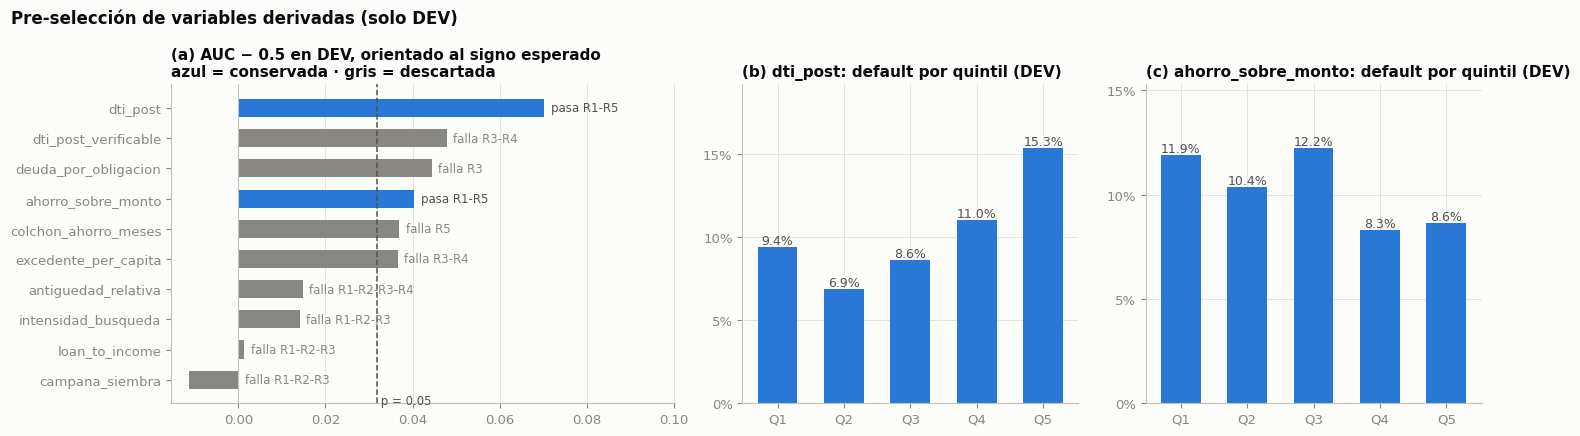

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.5, 1, 1]})

# (a) Señal en DEV orientada al signo esperado: > 0 = ordena el riesgo en la dirección esperada.
ax = axes[0]
e = ev.assign(senal=[(a - 0.5) * (1 if s == "+" else -1) for a, s in zip(ev.auc_dev, ev.signo_esperado)])
e = e.sort_values("senal")
colores = [BLUE if d == "Conservada" else MUTED for d in e.decision]
ax.barh(e.feature, e.senal, color=colores, height=0.6)
reglas = ["R1", "R2", "R3", "R4", "R5"]
for y_, (_, r) in enumerate(e.iterrows()):
    fallas = [k for k in reglas if not r[k]]
    etiqueta = "pasa R1-R5" if not fallas else "falla " + "-".join(fallas)
    ax.text(max(r.senal, 0) + 0.0015, y_, etiqueta, va="center", fontsize=8.5, color=INK_2 if not fallas else MUTED)
ax.set_xlim(right=e.senal.max() + 0.03)
n1, n0 = int(dev_pool[cfg.TARGET].sum()), int((1 - dev_pool[cfg.TARGET]).sum())
umbral = 1.96 * validation.auc_standard_error(0.5, n1, n0)
ax.axvline(umbral, color=INK_2, lw=1.1, ls="--")
ax.axvline(0, color=AXIS, lw=0.8)
ax.text(umbral, -0.9, " p = 0.05", color=INK_2, fontsize=8.5, va="bottom")
ax.set_title("(a) AUC − 0.5 en DEV, orientado al signo esperado\nazul = conservada · gris = descartada")
ax.grid(axis="y", visible=False)

# (b) y (c) Default por quintil en DEV de las dos derivadas conservadas.
for ax, col in zip(axes[1:], features.DERIVED_CANDIDATES):
    q = pd.qcut(dev_pool[col], 5, duplicates="drop")
    t = dev_pool.groupby(q, observed=True)[cfg.TARGET].agg(["size", "mean"])
    etiquetas = [f"Q{i+1}" for i in range(len(t))]
    ax.bar(etiquetas, t["mean"], color=BLUE, width=0.6)
    for x_, v in enumerate(t["mean"]):
        ax.text(x_, v, f"{v:.1%}", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set_title(f"({'b' if col == features.DERIVED_CANDIDATES[0] else 'c'}) {col}: default por quintil (DEV)")
    pct_axis(ax)
    ax.set_ylim(0, t["mean"].max() * 1.25)
fig.suptitle("Pre-selección de variables derivadas (solo DEV)", x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
savefig(fig, "fig10_features_derivadas")
plt.show()


**Qué muestra la pre-selección.** De 10 derivadas evaluadas se conservan **2**:

- **`dti_post`** (AUC 0.570 en DEV, mismo signo en 2021-2022 y 2023). Como predictor es **intercambiable con `dti`** (Spearman 0.83): en un logit lineal `dti` aporta algo sobre `dti_post` (p = 0.02) y no al revés (p = 0.61), pero por tramos, que es como trabaja un scorecard, ninguna aporta sobre la otra (p ≈ 0.21), y en VAL tampoco. Se conserva porque incorpora la cuota del crédito que se decide, así la PD reacciona si se contraoferta monto o plazo, y porque es la medida de la regla de capacidad de pago. El scorecard (6.5) elige una de las dos, no ambas.
- **`ahorro_sobre_monto`** (AUC 0.460, p = 0.017) es la única derivada de ahorro con aporte propio. Queda como candidata y en 6.5 compite con `savings_balance`.

Las otras 8 se descartan con evidencia:

- **`campana_siembra`, `intensidad_busqueda`, `antiguedad_relativa` y `loan_to_income` (R1-R2):** no tienen señal en DEV. En el caso de la campaña agrícola el signo es incluso contrario al esperado, lo que coincide con la ausencia de estacionalidad en 6.1.
- **`deuda_por_obligacion` (R3):** su señal es la de `monthly_debt_payment`; la construcción no agrega nada (p = 0.52).
- **`colchon_ahorro_meses` (R5):** repite a `ahorro_sobre_monto` (Spearman 0.83).
- **`dti_post_verificable` y `excedente_per_capita` (R3-R4):** no agregan sobre sus componentes y usan una variable sensible (efectivo, dependientes) sin pasar la prueba de necesidad de negocio. `dti_post_verificable` castigaba por construcción al cliente que cobra en efectivo, contrario al objetivo del caso. La verificación del ingreso en efectivo queda como disparador de revisión en la política, no como penalidad dentro del modelo.


In [17]:
display(features.discarded_doc(ev))


,feature,formula,motivo_descarte
0,colchon_ahorro_meses,savings_balance / cuota_estimada,R5: redundante con otra derivada conservada (a...
1,deuda_por_obligacion,monthly_debt_payment / (1 + active_loans),R3: no agrega información sobre sus propios co...
2,dti_post_verificable,(monthly_debt_payment + cuota_estimada) / (mon...,R3: no agrega información sobre sus propios co...
3,excedente_per_capita,(monthly_income - monthly_debt_payment - cuota...,R3: no agrega información sobre sus propios co...
4,antiguedad_relativa,"employment_tenure_months / ((age - 14) * 12), ...",R1: sin señal en DEV o con signo contrario al ...
5,intensidad_busqueda,bureau_inquiries_6m / (1 + active_loans),R1: sin señal en DEV o con signo contrario al ...
6,campana_siembra,1 si el mes de observation_date está entre set...,R1: sin señal en DEV o con signo contrario al ...
7,loan_to_income,requested_amount / monthly_income,R1: sin señal en DEV o con signo contrario al ...
8,monto_vs_mediana_region,requested_amount / mediana del monto en la reg...,AUC 0.501 en DEV; además introduce un estadíst...
9,mes_originacion,mes calendario de observation_date,Sin estacionalidad: el default no difiere por ...


## 9. Pipeline reproducible

Un único objeto de scikit-learn encadena: recálculo de `dti` y variables derivadas → winsorización → imputación → encoding. Los indicadores de faltante y las derivadas descartadas no entran a la matriz. Se ajusta **solo con DEV** y se aplica igual a VAL, OOT y a cualquier solicitud nueva, que es lo que evita diferencias entre entrenamiento y producción.

In [18]:
num_cols, cat_cols_pipe = pipeline.model_columns()
cols_in = pipeline.pipeline_input_columns()   # esquema de entrada fijo (candidatas; dti se recalcula)
print(f"Entradas del pipeline: {len(cols_in)} columnas de la solicitud")
print(f"Salida esperada: {len(num_cols)} numéricas (incluye derivadas) + {len(cat_cols_pipe)} categóricas a one-hot")

pipe = pipeline.build_pipeline(scale=True)
dev, val, oot = (pop[pop["sample"] == s] for s in cfg.SAMPLE_ORDER)
pipe.fit(dev[cols_in])             # se ajusta SOLO con DEV
X_dev, X_val, X_oot = (pipe.transform(m[cols_in]) for m in (dev, val, oot))

print(f"Matriz resultante -> DEV {X_dev.shape} | VAL {X_val.shape} | OOT {X_oot.shape}")
print("Mismas columnas en las tres muestras:", list(X_dev.columns) == list(X_val.columns) == list(X_oot.columns))
print("Faltantes tras el pipeline:", int(X_dev.isna().sum().sum()), int(X_val.isna().sum().sum()), int(X_oot.isna().sum().sum()))
display(pipe)

Entradas del pipeline: 19 columnas de la solicitud
Salida esperada: 19 numéricas (incluye derivadas) + 3 categóricas a one-hot
Matriz resultante -> DEV (3443, 32) | VAL (1151, 32) | OOT (1189, 32)
Mismas columnas en las tres muestras: True
Faltantes tras el pipeline: 0 0 0


,steps,"[('features', ...), ('prep', ...)]"
,transform_input,None
,memory,None
,verbose,False
,annual_rate,None
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [19]:
# Control 1: los topes de winsorización se aprendieron en DEV y se aplican a OOT sin recalcularse.
winsor = pipe.named_steps["prep"].named_transformers_["num"].named_steps["winsor"]
topes = pd.DataFrame({"tope_inferior_p1": winsor.lower_, "tope_superior_p99": winsor.upper_})
display(topes.loc[["savings_balance", "monthly_debt_payment", "distance_to_branch_km", "requested_amount"]])
print("Máximo de savings_balance en OOT antes del pipeline:", f"{oot['savings_balance'].max():,.0f}")
print("Máximo tras el pipeline (escala estandarizada, ya acotado):", f"{X_oot['savings_balance'].max():.3f}")

# Control 2: ninguna variable prohibida entró a la matriz final.
prohibidas = set(data.forbidden_pd_features())
print("Variables prohibidas presentes en la matriz:", sorted(prohibidas & set(X_dev.columns)) or "ninguna")

# Control 3: el pipeline puede puntuar una solicitud individual, como lo hará el servicio de scoring.
una_solicitud = raw.iloc[[0]][cols_in]
print("Una sola solicitud transformada:", pipe.transform(una_solicitud).shape)
# Control 4: indicadores de faltante y derivadas descartadas quedan fuera de la matriz del modelo.
fuera = (set(features.POLICY_FLAGS) | set(features.SCREENING_SPEC)) - set(features.DERIVED_CANDIDATES)
print("Indicadores o descartadas presentes en la matriz:", sorted(fuera & set(X_dev.columns)) or "ninguna")

# Control 5: sin ingreso no hay dti antes de imputar (la regla de consistencia se aplica dentro del pipeline).
fx_dev = pipe.named_steps["features"].transform(dev[cols_in])
print("DEV sin ingreso:", int(dev["monthly_income"].isna().sum()), "| sin dti tras FeatureBuilder:", int(fx_dev["dti"].isna().sum()))


,tope_inferior_p1,tope_superior_p99
savings_balance,215.9754,"29,889.4206"
monthly_debt_payment,66.4990,"5,160.1310"
distance_to_branch_km,1.4000,57.5160
requested_amount,"1,295.9108","29,522.4966"


Máximo de savings_balance en OOT antes del pipeline: 66,016
Máximo tras el pipeline (escala estandarizada, ya acotado): 5.231
Variables prohibidas presentes en la matriz: ninguna
Una sola solicitud transformada: (1, 32)
Indicadores o descartadas presentes en la matriz: ninguna
DEV sin ingreso: 85 | sin dti tras FeatureBuilder: 85


Los controles son los que se van a auditar más adelante: los topes se aprenden una sola vez en DEV (el máximo de ahorros en OOT, S/ 66,016, queda acotado al tope de DEV de S/ 29,889), ninguna variable prohibida, indicador o derivada descartada llega a la matriz, el `dti` no existe sin ingreso, y el pipeline funciona con **una sola solicitud**, que es exactamente el modo en que lo llamará el servicio de scoring.

## 10. Data Dictionary técnico

Extiende el catálogo de 6.2 con las decisiones de tratamiento tomadas en esta sección.

In [20]:
dic_tec = data_dictionary.technical_dictionary()
display(dic_tec[["variable", "origen", "rol", "uso_pd", "transformacion", "imputacion", "encoding",
                 "riesgo_leakage", "uso_final"]])
dic_tec.to_csv(cfg.TABLES / "diccionario_tecnico.csv", index=False)
print(f"Variables documentadas: {len(dic_tec)} ({int((dic_tec.origen == 'Original del dataset').sum())} originales + "
      f"{int((dic_tec.origen == 'Derivada en 6.3').sum())} derivadas en uso + "
      f"{int((dic_tec.origen == 'Derivada evaluada y descartada en 6.3').sum())} derivadas descartadas)")

,variable,origen,rol,uso_pd,transformacion,imputacion,encoding,riesgo_leakage,uso_final
0,application_id,Original del dataset,ID,No,No se transforma,No aplica,No aplica,No aplica,Trazabilidad del scoring
1,observation_date,Original del dataset,Tiempo,No,No se transforma,No aplica,No aplica,Ninguno si solo se usa para cortes temporales,Split DEV/VAL/OOT y seguimiento de cosechas
2,entity,Original del dataset,Metadato,No,No se transforma,No aplica,No aplica,No aplica,No se usa
3,product,Original del dataset,Metadato,No,No se transforma,No aplica,No aplica,No aplica,No se usa
4,age,Original del dataset,Solicitud,Candidata (fairness),Winsorización p1-p99 (topes ajustados en DEV),Mediana de DEV,No aplica (numérica),Bajo: medida en T0,Modelo PD sujeto a revisión de discriminación ...
5,region,Original del dataset,Solicitud,Candidata (fairness),No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD sujeto a revisión de discriminación ...
6,channel,Original del dataset,Proceso,Candidata,No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD
7,employment_type,Original del dataset,Solicitud,Candidata,No se transforma,Moda de DEV,One-hot; una categoría no vista en producción ...,Bajo: medida en T0,Modelo PD
8,monthly_income,Original del dataset,Solicitud,Candidata,Winsorización p1-p99 (topes ajustados en DEV),Mediana de DEV (faltante compatible con MCAR);...,No aplica (numérica),Medio: declarado y poco verificable; el riesgo...,Modelo PD
9,employment_tenure_months,Original del dataset,Solicitud,Candidata,Winsorización p1-p99 (topes ajustados en DEV);...,Mediana de DEV,No aplica (numérica),Bajo: medida en T0,Modelo PD


Variables documentadas: 55 (41 originales + 6 derivadas en uso + 8 derivadas descartadas)


## 11. Persistencia y resumen de decisiones

In [21]:
cols_guardar = [cfg.ID_COL, cfg.DATE_COL, "sample", cfg.TARGET] + candidatas + features.DERIVED_FEATURES
pop_fx[cols_guardar].to_csv(cfg.DATA_PROCESSED / "pd_population_features.csv", index=False)
print("Guardado: data/processed/pd_population_features.csv", pop_fx[cols_guardar].shape)
print("Tablas nuevas:", sorted(p.name for p in cfg.TABLES.glob("*.csv") if p.name.startswith(("calidad_", "features_", "diccionario_", "faltantes_"))))
print("Figuras nuevas:", sorted(p.name for p in cfg.FIGURES.glob("fig0[89]*.png")) + sorted(p.name for p in cfg.FIGURES.glob("fig10*.png")))

Guardado: data/processed/pd_population_features.csv (5783, 30)
Tablas nuevas: ['calidad_cardinalidad.csv', 'calidad_completitud.csv', 'calidad_estabilidad_psi.csv', 'calidad_outliers.csv', 'calidad_reglas_consistencia.csv', 'diccionario_tecnico.csv', 'faltantes_historial_buro.csv', 'faltantes_mecanismo.csv', 'features_derivadas_doc.csv', 'features_evaluacion.csv']
Figuras nuevas: ['fig08_winsorizacion.png', 'fig09_estabilidad_temporal.png', 'fig10_features_derivadas.png']


| Decisión | Definición adoptada | Evidencia |
|---|---|---|
| Faltantes | Compatibles con MCAR; imputación por mediana (numéricas) y moda (categóricas) ajustada en DEV. Indicadores solo para política y monitoreo; sin score de buró ≠ thin-file | Secciones 2 y 9 |
| Duplicados | Ninguna acción: no existen en la base | Sección 3 |
| Inconsistencias | Se conservan los registros; `dti` se recalcula (sin ingreso no hay dti); extremos acotados por winsorización y reportados a captura | Sección 4 |
| Outliers | Winsorización p1-p99 con topes de DEV, sin eliminar registros | Sección 5 y `fig08` |
| Categóricas | One-hot simple (4-5 niveles, sin categorías raras); categorías no vistas quedan en ceros | Secciones 6 y 9 |
| Estabilidad | Variables estables (PSI máximo 0.017); el target sí se desplaza y exigirá recalibración | Sección 7 y `fig09` |
| Variables derivadas | 10 evaluadas con protocolo R1-R5 solo en DEV: 2 candidatas (`dti_post`, `ahorro_sobre_monto`), 1 insumo y 3 indicadores de política; 8 descartadas con evidencia (más 2 descartadas antes) | Sección 8 y `fig10` |
| Pipeline | Un solo objeto ajustado en DEV, aplicable a una solicitud individual; 19 columnas de entrada y 32 en la matriz | Sección 9 |
| Diccionario técnico | 55 variables (41 originales, 6 derivadas en uso y 8 descartadas) con transformación, imputación, encoding, riesgo de leakage y uso final | Sección 10 |